In [1]:
import pandas as pd
import numpy as np

import joblib

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv(r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\data\SmartShop_Portfolio_Dataset.csv")

df.head()

,Interaction_ID,Customer_ID,Product_ID,Category,Brand,Age,Gender,Region,Membership,Season,...,Recommendation_Score,Purchase_Status,Product_Rating,Customer_Lifetime_Value,Churn_Risk,Campaign_Response,Device,Payment_Method,Stock_Level,Delivery_Days
0,1,100001,4582,Books,PrimeGear,56,Male,South,Silver,Winter,...,54,0,3.7,138.29,42,1,Mobile,Card,357,7
1,2,100002,8527,Fashion,FreshMart,23,Female,East,Bronze,Summer,...,53,0,4.0,176.18,42,0,Desktop,UPI,437,4
2,3,100003,3677,Toys,FreshMart,35,Male,East,Gold,Spring,...,91,1,4.7,4254.82,7,1,Desktop,UPI,108,10
3,4,100004,5304,Grocery,EcoLife,43,Female,South,Gold,Summer,...,83,1,3.9,3154.76,20,0,Mobile,Card,405,7
4,5,100005,6573,Fashion,BookNest,45,Male,West,Silver,Spring,...,90,1,5.0,3594.27,15,0,Tablet,Wallet,430,9


In [4]:
target = "Product_Rating"

In [5]:
X = df.drop(columns=[target])

y = df[target]

In [6]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [8]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [9]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [12]:
linear_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
linear_predictions = linear_pipeline.predict(X_test)

In [14]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE :", linear_rmse)
print("R² :", linear_r2)

Linear Regression Results
-------------------------
MAE : 0.2900504286745109
RMSE : 0.33625747813403967
R² : 0.5789694851192395


In [15]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

In [16]:
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

In [17]:
grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [18]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,"Pipeline(step...l', Ridge())])"
,param_grid,"{'model__alpha': [0.01, 0.1, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [19]:
print("Best Alpha:")
print(grid_search.best_params_)

Best Alpha:
{'model__alpha': 10}


In [20]:
best_ridge = grid_search.best_estimator_

In [21]:
ridge_predictions = best_ridge.predict(
    X_test
)

In [22]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression Results")
print("------------------------")
print("MAE :", ridge_mae)
print("RMSE :", ridge_rmse)
print("R² :", ridge_r2)

Ridge Regression Results
------------------------
MAE : 0.2900990657274398
RMSE : 0.33624537566536067
R² : 0.578999791757769


In [23]:
comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],

    "MAE": [
        linear_mae,
        ridge_mae
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.290050,0.336257,0.578969
1,Ridge Regression,0.290099,0.336245,0.579000


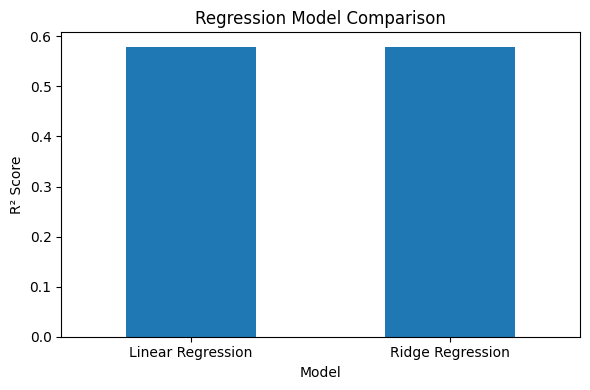

In [24]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Regression Model Comparison")

plt.ylabel("R² Score")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [25]:
plt.savefig(
    "../outputs/figures/regression_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [26]:
joblib.dump(
    best_ridge,
    "../models/best_ridge_model.pkl"
)

['../models/best_ridge_model.pkl']

Regression Insights
Linear Regression provides a baseline model for predicting product ratings.
Ridge Regression helps reduce overfitting by applying L2 regularization.
GridSearchCV automatically identifies the optimal alpha value.
The model predicts customer ratings based on browsing behavior, purchase history, recommendation score, membership level, and other customer/product features.